<a href="https://colab.research.google.com/github/arkadasgupta07/DevSoc-Assignments/blob/main/DevSoc_AIML_Assgn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import matplotlib.pyplot as plt & import seaborn as sns: These are our visualization toolkits. We use them to draw charts, graphs, and the confusion matrix later on.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# The sklearn (Scikit-Learn) Imports:
# Scikit-Learn is the main machine learning library in Python. We import specific tools from it:
# from sklearn.model_selection import train_test_split: This tool will randomly chop our dataset into a "training" piece and a "testing" piece.
# from sklearn.preprocessing import StandardScaler, LabelEncoder: These tools help translate our data into a format the machine learning math can actually understand (scaling numbers and converting text to numbers).
# from sklearn.metrics import accuracy_score...: These are our grading rubrics. They will calculate how well our models perform.

# Load the dataset (Make sure to update the path to where you downloaded the file)
df = pd.read_csv('/dataset.csv')

# Load the dataset directly from the Google Drive link
# url = "https://drive.google.com/uc?export=download&id=1k1YVdYwc-kVtUDjfTi18PnqGZtaeHrOF"
# df = pd.read_csv(url)

#########################################################

# For demonstration, assuming 'df' is loaded.
# Many features in the Obesity dataset are categorical. We need to encode them.
def preprocess_data(df):
    # Separate features and target
    # Assuming the target column is named 'NObeyesdad' (standard for this dataset) or 'Obesity_Risk'
    target_col = 'NObeyesdad' if 'NObeyesdad' in df.columns else df.columns[-1]
    # This looks for the target column we want to predict. In the standard Obesity dataset, it's called 'NObeyesdad'.
    # If it can't find that exact name, it defaults to the very last column in the dataset (df.columns[-1]).

#########################################################

    X = df.drop(columns=[target_col])
    y = df[target_col]
    # ✂️ 1. Separating Inputs from Outputs
    # Machine learning models need to know what information they are allowed to look at (the inputs) and what answer they are trying to guess (the output).

    # X = df.drop(columns=[target_col])
    # What it does: This creates our "Features" (the inputs). We take the entire dataset (df) and explicitly drop the column containing the answers (target_col). X now holds all the clues (like age, weight, eating habits).
    # y = df[target_col]
    # What it does: This creates our "Target" (the output). We isolate just that single column we want to predict (the obesity risk level) and save it as y.

#########################################################


    # Encode categorical features
    X = pd.get_dummies(X, drop_first=True)


    # 🧮 2. Converting Text to Numbers (Encoding)
    # Machine learning models cannot do math on words like "Yes", "No", or "Frequently". We must translate text into numbers.

    # X = pd.get_dummies(X, drop_first=True)

    # What it does: This handles text inside our features (X). It uses a technique called One-Hot Encoding.
    # If you have a column for "Gender" with "Male" and "Female", it creates new columns containing 1s and 0s (e.g., Gender_Male: 1 means Male, 0 means Female).

    # drop_first=True: This drops the very first category it creates to avoid redundant data
    # (if Gender_Male is 0, the model already knows the person is Female, so we don't need a Gender_Female column).
    # Consequence if not used:-  Having redundant columns perfectly predicting each other causes a mathematical issue in machine learning known as multicollinearity (or the "dummy variable trap"). It can confuse certain models and make them perform poorly.

#########################################################

    # Encode target variable
    le = LabelEncoder()
    y = le.fit_transform(y)

    # What it is: Scikit-Learn (our ML library) has a specific tool called LabelEncoder.
    # Its sole job is to look at a single column of text categories and assign a unique integer to each one.

    # What this line does: Think of LabelEncoder() as a physical tool sitting in a toolbox (our ML Library, Scikit-Learn). Before we can use it, we have to take it out and hold it in our hand.
    # By writing le = LabelEncoder(), we are taking that tool out and giving it a short, easy nickname (le) so we can use it on the next line.

    # y = le.fit_transform(y) (Using the Tool)
    # This line is where the actual translation happens for our target variable (the Obesity Risk category).
    # It combines two steps into one:
    # Step 1: The fit part: The tool looks at the entire y column and learns what all the unique categories are. It essentially builds a secret dictionary in its memory. For example:Insufficient_Weight-->0, Normal_Weight-->1, Overweight_Level_I-->2, Obesity_Type_I-->3
    # Step 2: The transform part: Once it knows the dictionary, it goes through every single row in your dataset and literally replaces the text with the corresponding number. The Result: By setting y = ..., we overwrite the old text-based target column with our shiny new, purely numerical target column.
    # Now the machine learning model can safely perform mathematical calculations to predict those numbers!


 #########################################################

    return X, y, le.classes_


X, y, class_names = preprocess_data(df)

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store results for comparison
results = {}

# Helper function to evaluate models
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = [acc, prec, rec, f1]

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

--- Baseline (Decision Tree) ---
Accuracy : 0.8461
Precision: 0.8456
Recall   : 0.8461
F1-Score : 0.8458



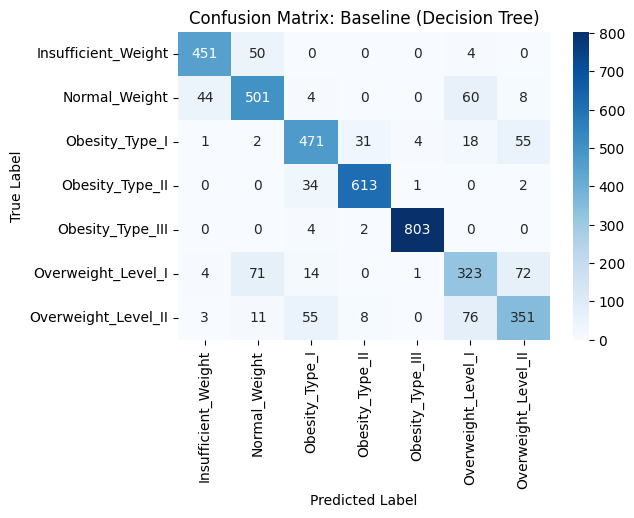

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train
baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train_scaled, y_train)

# Evaluate
evaluate_model("Baseline (Decision Tree)", baseline_dt, X_test_scaled, y_test)

--- Bagging (Random Forest) ---
Accuracy : 0.8988
Precision: 0.8982
Recall   : 0.8988
F1-Score : 0.8981



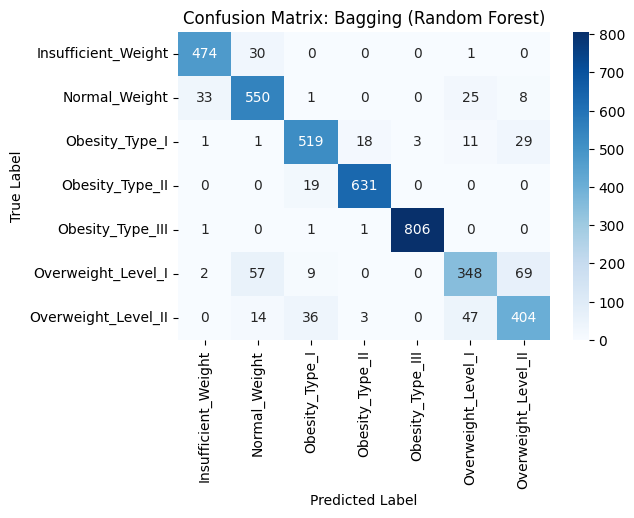

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

evaluate_model("Bagging (Random Forest)", rf_model, X_test_scaled, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:27:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Boosting (XGBoost) ---
Accuracy : 0.9104
Precision: 0.9103
Recall   : 0.9104
F1-Score : 0.9103



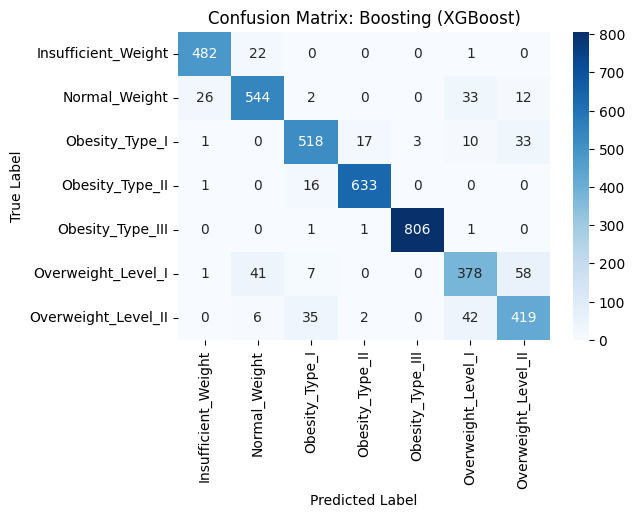

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 23
[LightGBM] [Info] Start training from score -2.107657
[LightGBM] [Info] Start training from score -1.907572
[LightGBM] [Info] Start training from score -1.964755
[LightGBM] [Info] Start training from score -1.855022
[LightGBM] [Info] Start training from score -1.635117
[LightGBM] [Info] Start training from score -2.146046
[LightGBM] [Info] Start training from score -2.107657


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Boosting (LightGBM) ---
Accuracy : 0.9094
Precision: 0.9090
Recall   : 0.9094
F1-Score : 0.9090



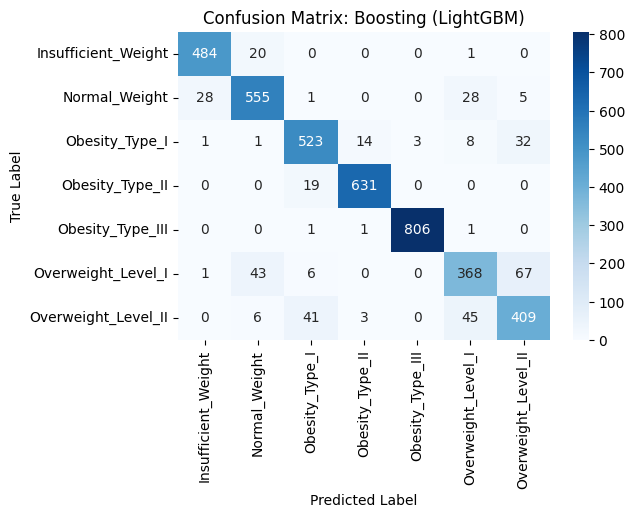

In [ ]:
import xgboost as xgb
import lightgbm as lgb

# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
evaluate_model("Boosting (XGBoost)", xgb_model, X_test_scaled, y_test)

# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train_scaled, y_train)
evaluate_model("Boosting (LightGBM)", lgb_model, X_test_scaled, y_test)

--- Hard Voting ---
Accuracy : 0.8940
Precision: 0.8932
Recall   : 0.8940
F1-Score : 0.8935



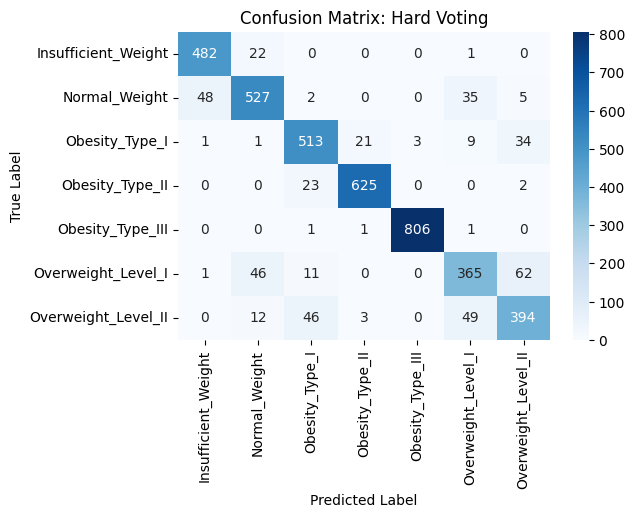

--- Weighted Soft Voting ---
Accuracy : 0.9003
Precision: 0.8999
Recall   : 0.9003
F1-Score : 0.8999



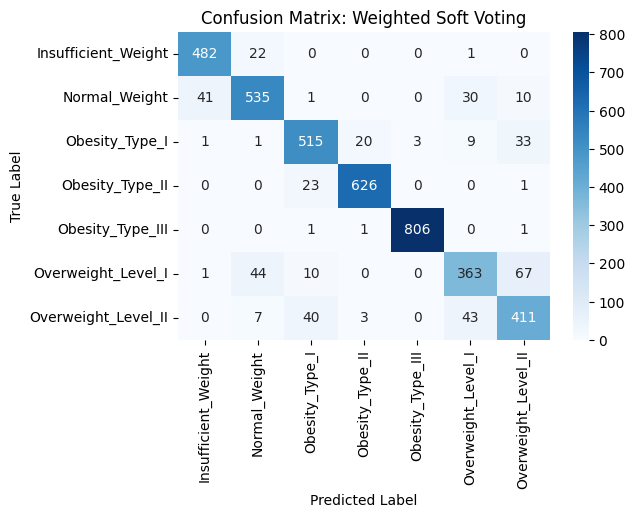

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

# Let's create a diverse set of models
m1 = DecisionTreeClassifier(max_depth=5, random_state=42)
m2 = LogisticRegression(max_iter=1000, random_state=42)
m3 = RandomForestClassifier(n_estimators=50, random_state=42)

# Hard Voting
hard_voting = VotingClassifier(estimators=[('dt', m1), ('lr', m2), ('rf', m3)], voting='hard')
hard_voting.fit(X_train_scaled, y_train)
evaluate_model("Hard Voting", hard_voting, X_test_scaled, y_test)

# Soft Voting with Weights (giving more weight to Random Forest)
soft_voting = VotingClassifier(estimators=[('dt', m1), ('lr', m2), ('rf', m3)], voting='soft', weights=[1, 1, 2])
soft_voting.fit(X_train_scaled, y_train)
evaluate_model("Weighted Soft Voting", soft_voting, X_test_scaled, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:28:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:28:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:28:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:28:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

--- Stacking ---
Accuracy : 0.9114
Precision: 0.9113
Recall   : 0.9114
F1-Score : 0.9113



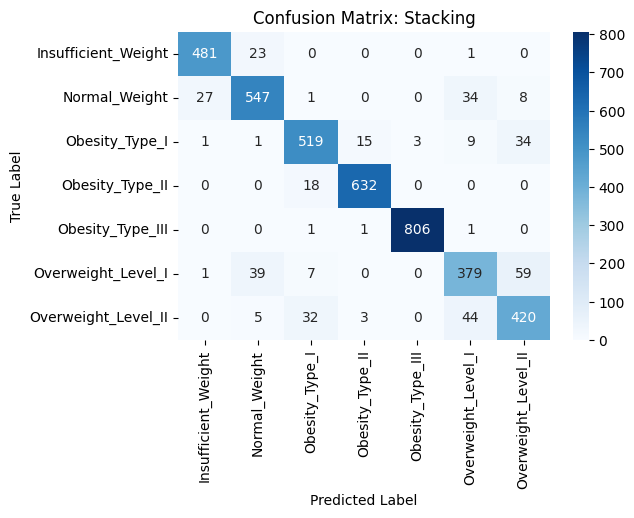

In [ ]:
from sklearn.ensemble import StackingClassifier

# Base models
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
]

# Meta learner
meta_learner = LogisticRegression()

stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stacking_model.fit(X_train_scaled, y_train)

evaluate_model("Stacking", stacking_model, X_test_scaled, y_test)


--- Final Model Comparison ---
                          Accuracy  Precision    Recall  F1-Score
Baseline (Decision Tree)  0.846098   0.845625  0.846098  0.845812
Bagging (Random Forest)   0.898844   0.898191  0.898844  0.898113
Boosting (XGBoost)        0.910405   0.910278  0.910405  0.910263
Boosting (LightGBM)       0.909441   0.908959  0.909441  0.909049
Hard Voting               0.894027   0.893226  0.894027  0.893458
Weighted Soft Voting      0.900289   0.899926  0.900289  0.899860
Stacking                  0.911368   0.911307  0.911368  0.911276


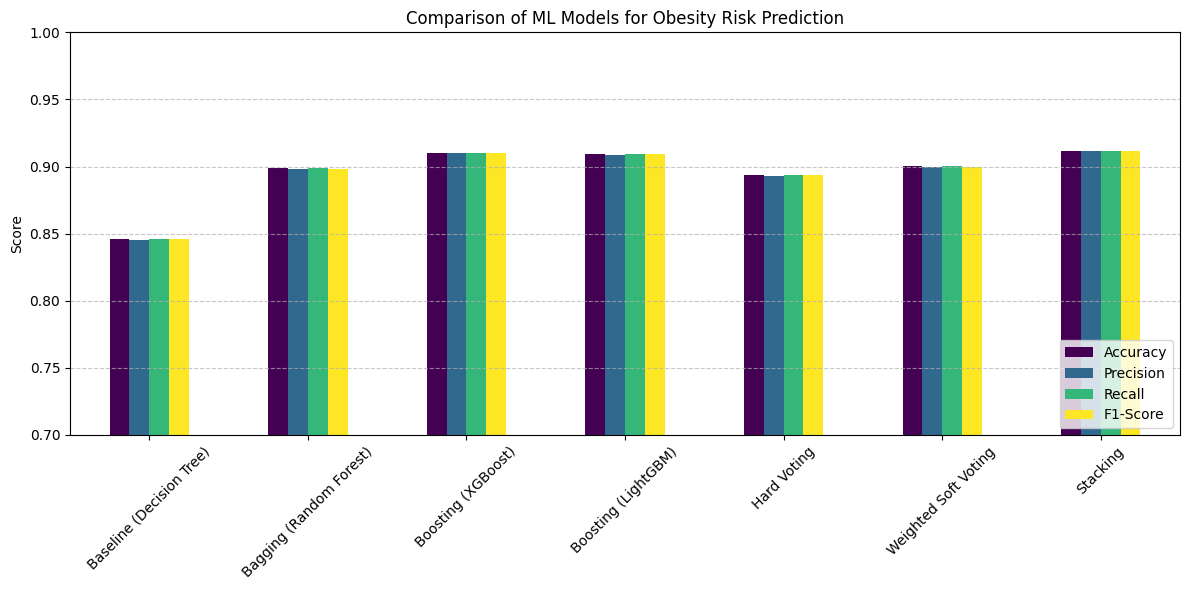

In [ ]:
# Convert results dictionary to a DataFrame
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print("\n--- Final Model Comparison ---")
print(results_df)

# Plotting the comparison
results_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparison of ML Models for Obesity Risk Prediction')
plt.ylabel('Score')
plt.ylim(0.7, 1.0) # Adjust based on your actual results to make differences visible
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()